# **INSTRUCTOR EFFECTIVENESS MODELING**

## Introduction

This project aims to evaluate instructor effectiveness using learner performance, engagement, and feedback metrics. Since the dataset contains batch-level information, the data is aggregated at the instructor level to create meaningful features. Machine learning models are then trained to classify instructors into Low, Medium, and High effectiveness tiers.

## Importing Libraries

In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Data Loading

In [6]:
df = pd.read_csv('instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')
df

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,B_1131,I_047,C_17,0.589309,19.227979,46.242023,0.433437,0.848756,0.641781,0.261656,4.339478,0.643116
1996,B_1295,I_037,C_25,0.980000,36.737265,93.249093,0.103561,1.000000,0.688175,0.375195,4.912936,0.959988
1997,B_0861,I_033,C_06,0.531447,24.907878,83.990693,0.512266,0.918924,0.598276,0.271701,4.211113,0.773437
1998,B_1460,I_069,C_10,0.641025,22.395362,80.044231,0.317231,0.558183,0.575629,0.135500,4.182141,0.962627


## Dataset Exploration

In [7]:
#Reading starting 5 rows
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [9]:
#Perform EDA(Exploratory Data Analysis)
df.shape

(2000, 12)

In [21]:
df.info()
#Here we will see the information about the dataset i.e datatype , non-null count and the features we have

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [22]:
df.describe()
#Here we will see the all main statistic terms which we need to analyze the data

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [23]:
df.isnull().sum()
#Here we will see there is no null value in our dataset

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [84]:
#Check for duplicate records
df.duplicated().sum()
#Here we will see there is no null value in the data
#Means we have correct data with no missing a d duplicated values

np.int64(0)

In [25]:
#Creating plots for numerical Dataset
dataset = ['completion_rate','avg_score_improvement','avg_quiz_score','dropout_rate','avg_watch_time','assignment_submission_rate','forum_activity_rate','avg_feedback_score','feedback_response_rate']

In [86]:
plt.style.use('ggplot')

# Visualization


### Histogram

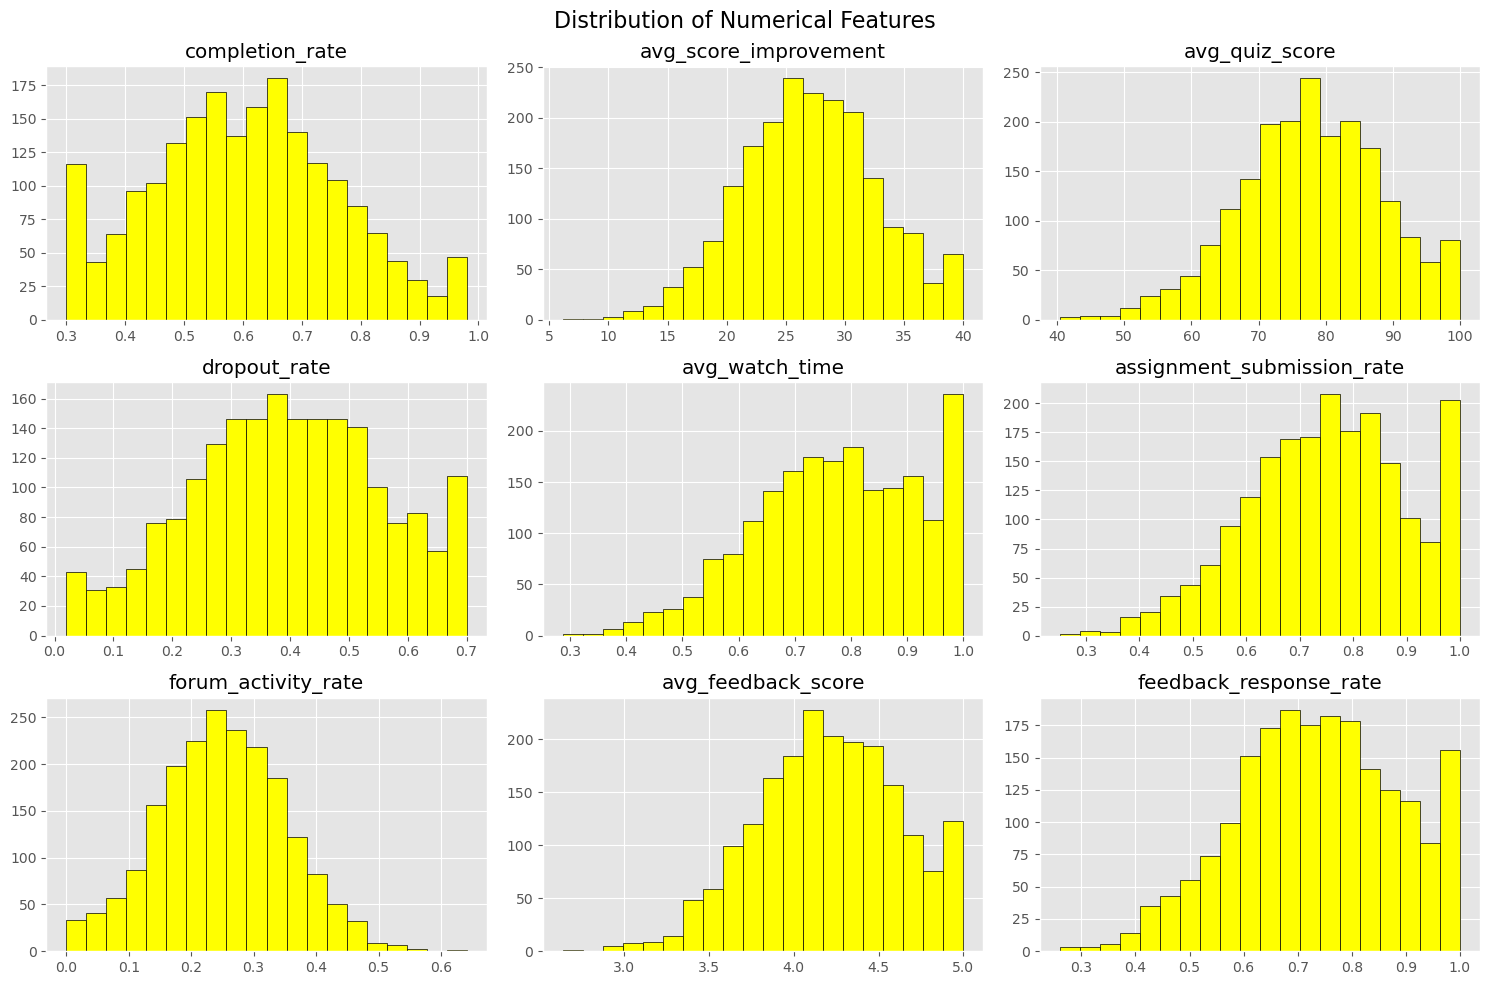

In [98]:
df[dataset].hist(figsize=(15,10),
    bins=20,
    edgecolor='black',color = 'Yellow'
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()
#Here we will see the histogram of each numerical features

### Observations from Histograms

- **Completion Rate:** Most batches have completion rates between **0.50 and 0.75**, indicating that the majority of learners successfully complete the courses.

- **Average Score Improvement:** The distribution is approximately bell-shaped, with most values ranging between **20 and 35**, suggesting consistent learning improvements across batches.

- **Average Quiz Score:** Most quiz scores fall between **70 and 85**, indicating generally good learner performance.

- **Dropout Rate:** Most dropout rates lie between **0.20 and 0.50**, while very high dropout rates are relatively uncommon.

- **Average Watch Time:** The majority of values are above **0.65**, showing that learners spend a significant amount of time watching course videos.

- **Assignment Submission Rate:** Most batches have submission rates above **0.60**, indicating strong learner participation in assignments.

- **Forum Activity Rate:** Forum activity is generally lower than other engagement metrics, with most values concentrated between **0.15 and 0.35**.

- **Average Feedback Score:** Feedback ratings are mostly between **3.8 and 4.5**, suggesting that learners are generally satisfied with the instructors.

- **Feedback Response Rate:** Most response rates fall between **0.60 and 0.90**, indicating that a large proportion of learners provide feedback.

### Overall Observation

Overall, the dataset shows that most learner outcome and engagement metrics are concentrated in the moderate-to-high range. The distributions do not exhibit extreme irregularities, making the dataset suitable for further feature engineering and machine learning analysis.

### Boxplot

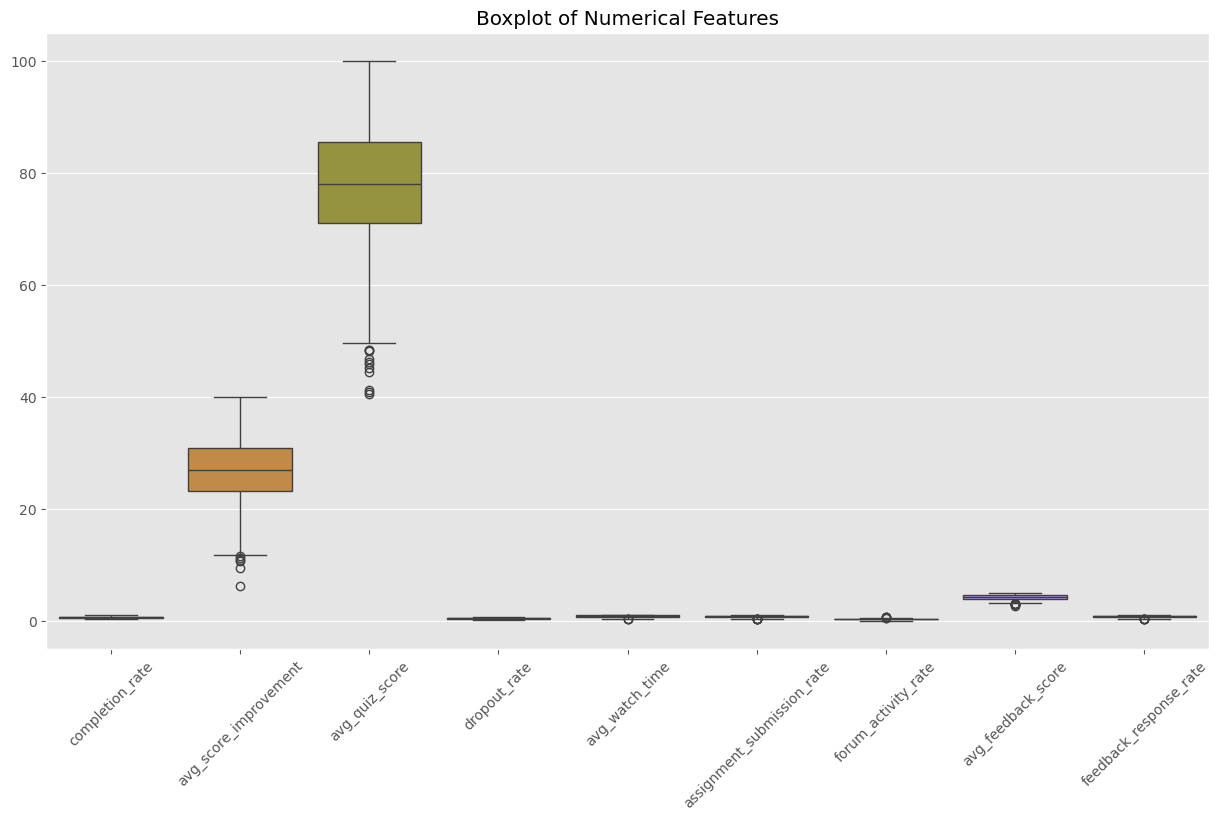

In [99]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[dataset])

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

## Observations from Boxplots

- **Completion Rate:** The median completion rate is relatively high, and the values are closely distributed, indicating consistent learner completion across most batches.

- **Average Score Improvement:** A few lower-end outliers are present, suggesting that some batches experienced lower learning improvements than the majority.

- **Average Quiz Score:** Most quiz scores are concentrated between **70 and 85**, with only a few lower outliers. This indicates generally strong learner performance.

- **Dropout Rate:** The dropout rate has a moderate spread with no significant extreme outliers, indicating relatively stable dropout levels across batches.

- **Average Watch Time:** Most learners have high watch times, with only a few lower outliers, suggesting strong engagement with video content.

- **Assignment Submission Rate:** Assignment submission rates are generally high, indicating active learner participation across most batches.

- **Forum Activity Rate:** Forum activity shows greater variability than other engagement metrics, suggesting differences in learner interaction across batches.

- **Average Feedback Score:** Feedback scores are tightly clustered around **4.0–4.5**, indicating consistently positive learner satisfaction.

- **Feedback Response Rate:** Most batches have high feedback response rates, with only a few lower values.

### Overall Observation

Overall, the boxplots indicate that most numerical features have moderate variability and relatively few outliers. Learner engagement, completion, and feedback metrics are generally concentrated at higher values, suggesting positive learner outcomes. Although a few lower outliers are observed in features such as average score improvement and quiz scores, no feature exhibits excessive variability. Overall, the dataset appears clean and suitable for further feature engineering and machine learning analysis.

> **Note:** The variables are measured on different scales (e.g., quiz scores range from 0–100, feedback scores from 1–5, and several engagement metrics from 0–1). As a result, features with larger ranges appear more prominent in the combined boxplot. This difference in scale should be considered during feature engineering.

### Correlation Heatmap

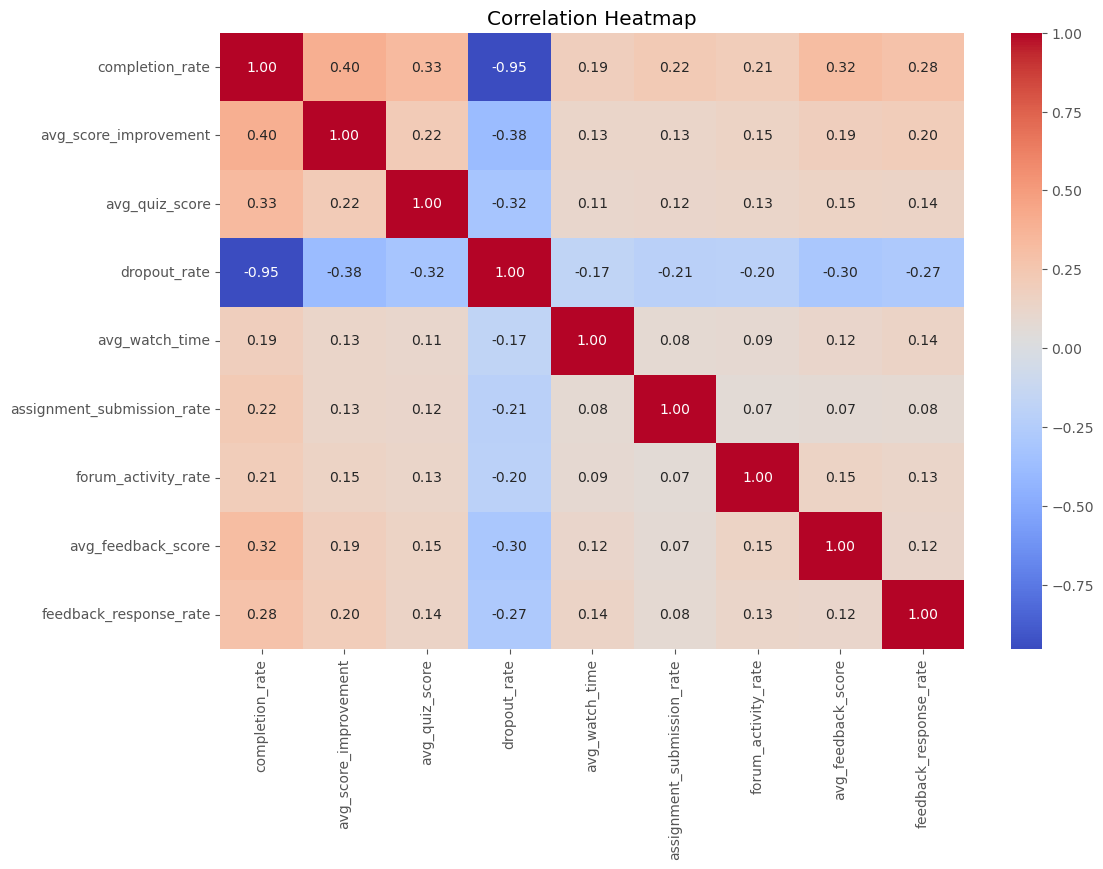

In [101]:
plt.figure(figsize=(12,8))
corr = df[dataset].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

## Observations from Correlation Heatmap

- **Completion Rate** shows a strong positive correlation with **Assignment Submission Rate** and **Average Watch Time**, indicating that learners who are more engaged are more likely to complete the course.

- **Dropout Rate** has a negative correlation with **Completion Rate**, suggesting that higher dropout is associated with lower course completion.

- **Average Feedback Score** is positively correlated with **Average Quiz Score** and **Completion Rate**, indicating that instructors receiving better feedback often have learners with better outcomes.

- **Forum Activity Rate** has a weak-to-moderate positive correlation with other engagement metrics, suggesting that discussion participation contributes to learner engagement but is not the strongest factor.

- Most features exhibit weak to moderate correlations, indicating that each metric provides unique information without severe multicollinearity.

### Pairplot

In [ ]:
sns.pairplot(
    df[dataset],
    diag_kind='hist'
)
plt.show()

## Observations from Pairplot

- The diagonal plots show the distribution of each numerical feature, and most variables appear to have smooth, approximately bell-shaped or moderately skewed distributions.

- **Completion Rate** tends to show a positive relationship with **Average Watch Time**, **Assignment Submission Rate**, and **Average Feedback Score**, indicating that higher learner engagement is generally associated with better course completion.

- **Dropout Rate** appears to have a negative relationship with **Completion Rate** and other engagement metrics, suggesting that batches with higher dropout rates tend to have lower learner participation and completion.

- **Average Quiz Score** and **Average Score Improvement** exhibit a moderate positive relationship, indicating that learners who improve more also tend to achieve better quiz performance.

- **Assignment Submission Rate**, **Average Watch Time**, and **Feedback Response Rate** show positive associations with one another, suggesting that engaged learners are more likely to participate in multiple course activities.

- No strong nonlinear relationships or distinct clusters are observed, indicating that the dataset has relatively consistent patterns across different batches.

### Overall Observation

Overall, the pairplot suggests that learner engagement metrics and performance metrics are positively related, while dropout rate tends to move in the opposite direction. The relationships appear moderate rather than extremely strong, indicating that multiple factors collectively influence instructor effectiveness.

## EDA Summary

- The dataset contains no significant missing values or duplicate records.
- Most numerical features show moderate variability with few extreme outliers.
- Learner engagement metrics generally have positive relationships with learner outcomes.
- Dropout rate tends to have a negative relationship with completion rate.
- Overall, the dataset is clean and suitable for further feature engineering and machine learning.

## Feature Engineering

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]

scaler = MinMaxScaler()

scaled_df = df.copy()
scaled_df[cols] = scaler.fit_transform(df[cols])

In [ ]:
scaled_df["effectiveness_score"] = (
      0.25 * scaled_df["completion_rate"]
    - 0.20 * scaled_df["dropout_rate"]
    + 0.15 * scaled_df["avg_score_improvement"]
    + 0.15 * scaled_df["avg_quiz_score"]
    + 0.10 * scaled_df["avg_watch_time"]
    + 0.05 * scaled_df["assignment_submission_rate"]
    + 0.05 * scaled_df["forum_activity_rate"]
    + 0.03 * scaled_df["avg_feedback_score"]
    + 0.02 * scaled_df["feedback_response_rate"]
)

Instructor effectiveness is not directly available in the dataset. Therefore, a custom effectiveness score was created by combining learner outcomes, engagement metrics, and learner feedback. Positive indicators such as completion rate, quiz score, and feedback contribute positively to the score, while dropout rate contributes negatively. Weights were assigned based on the assumed importance of each metric.

#### Aggregate Batch Data to Instructor Level

In [ ]:
instructor_df = scaled_df.groupby("instructor_id").agg({
    "completion_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "dropout_rate":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean",
    "effectiveness_score":"mean",
    "batch_id":"count"
}).rename(columns={"batch_id":"num_batches"}).reset_index()

#### Create Effectiveness Tiers

In [59]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

In [60]:
instructor_df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

#### Independent and Dependent Features 

In [97]:
X = instructor_df.drop(
    ["instructor_id","effectiveness_score","effectiveness_tier"],
    axis=1
)

y = instructor_df["effectiveness_tier"]

#### Train Test Split

In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3 , random_state = 42,stratify=y)

## Model Building

In this section, multiple machine learning models are trained to predict instructor effectiveness tiers. A baseline model (Logistic Regression) is first developed, followed by a Random Forest Classifier. The performance of both models is compared to identify the most suitable model for this classification task.

### **Logistic Regression**

Logistic Regression is used as the baseline classification model. Since it is sensitive to feature scales, the input features are standardized using StandardScaler before training.

In [91]:
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter = 1000, random_state = 42)
lr.fit(X_train_scaled , y_train)
lr_pred = lr.predict(X_test_scaled)
lr_pred

array(['Low', 'Low', 'Low', 'Medium', 'High', 'Medium', 'Medium', 'Low',
       'High', 'High', 'Low', 'Low', 'Medium', 'High', 'Medium', 'Low',
       'Low', 'Medium', 'High', 'High', 'Medium', 'Low', 'High', 'Medium',
       'High', 'Low', 'High', 'Medium', 'High', 'Low', 'High', 'Medium',
       'Low', 'High', 'Medium', 'Medium'], dtype=object)

### Logistic Regression Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix to assess its classification performance.

In [92]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 
print("Accuracy :", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

Accuracy : 0.8888888888888888
              precision    recall  f1-score   support

        High       0.83      0.83      0.83        12
         Low       1.00      1.00      1.00        12
      Medium       0.83      0.83      0.83        12

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.89      0.89      0.89        36

[[10  0  2]
 [ 0 12  0]
 [ 2  0 10]]


#### Logistic Regression Results

The Logistic Regression model achieved an overall **accuracy of 88.89%**, indicating that it correctly classified approximately 89% of the instructors into their respective effectiveness tiers.

The macro-average precision, recall, and F1-score are all **0.89**, demonstrating balanced performance across the three classes (Low, Medium, and High). This suggests that the model does not favor one class over another and performs consistently.

The **Low** effectiveness class was classified perfectly, achieving **100% precision, recall, and F1-score**. However, the **High** and **Medium** classes each achieved an F1-score of **0.83**, indicating that a few instructors were misclassified between these two categories.

Overall, Logistic Regression provides a strong baseline model for predicting instructor effectiveness tiers.

#### Confusion Matrix Interpretation

The confusion matrix shows that:

- All **12 Low-effectiveness instructors** were correctly classified.
- **10 out of 12 High-effectiveness instructors** were correctly classified, while **2 were misclassified**.
- **10 out of 12 Medium-effectiveness instructors** were correctly classified, while **2 were misclassified**.

These results indicate that the model distinguishes the **Low** effectiveness tier very well. Most prediction errors occur between the **High** and **Medium** effectiveness tiers, suggesting that these two classes share similar characteristics.

#### Observation

The Logistic Regression model achieved an accuracy of **88.89%**, demonstrating strong baseline performance. The model classified the **Low** effectiveness tier perfectly, while a small number of **High** and **Medium** instructors were confused with one another. This indicates that the features used are effective in distinguishing instructor performance, although the boundary between High and Medium tiers is less distinct.

The model provides a solid benchmark for comparison with the Random Forest model.

### **Random Forest Classifier**

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is well-suited for datasets containing nonlinear relationships and provides feature importance for model interpretation.

In [93]:
from sklearn.ensemble import RandomForestClassifier 
rfc = RandomForestClassifier(n_estimators=200,random_state=42)
rfc.fit(X_train,y_train)
rfc_pred = rfc.predict(X_test)
rfc

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression to ensure a fair comparison between the two models.

## Model Evaluation

In [94]:
print("Accuracy :", accuracy_score(y_test, rfc_pred))
print(classification_report(y_test, rfc_pred))
print(confusion_matrix(y_test, rfc_pred))

Accuracy : 0.9444444444444444
              precision    recall  f1-score   support

        High       1.00      0.83      0.91        12
         Low       1.00      1.00      1.00        12
      Medium       0.86      1.00      0.92        12

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.94        36
weighted avg       0.95      0.94      0.94        36

[[10  0  2]
 [ 0 12  0]
 [ 0  0 12]]


### Random Forest Results

The Random Forest Classifier achieved an overall **accuracy of 94.44%**, outperforming the Logistic Regression model. This indicates that the model correctly classified approximately **94%** of instructors into their respective effectiveness tiers.

The model achieved a **macro-average precision of 0.95**, **recall of 0.94**, and **F1-score of 0.94**, demonstrating strong and balanced performance across all three effectiveness categories.

The **Low** effectiveness tier was classified perfectly with **100% precision, recall, and F1-score**. The **Medium** tier also achieved perfect recall, while the **High** tier achieved perfect precision with only a small number of misclassifications.

Overall, the Random Forest model provides excellent predictive performance and is selected as the final model for this project.

### Confusion Matrix Interpretation

The confusion matrix shows that:

- **10 out of 12 High-effectiveness instructors** were correctly classified, while **2 were misclassified as Medium**.
- **All 12 Low-effectiveness instructors** were correctly classified.
- **All 12 Medium-effectiveness instructors** were correctly classified.

The model performs exceptionally well in distinguishing the three effectiveness tiers. The only classification errors occurred between the **High** and **Medium** categories, which is reasonable because these two groups may share similar learner outcome and engagement characteristics.

## **Model Comparison**

Two classification models were developed to predict instructor effectiveness tiers.

| Model | Accuracy | Precision | Recall | F1-score |
|-------|---------:|----------:|--------:|---------:|
| Logistic Regression | 88.89% | 0.89 | 0.89 | 0.89 |
| Random Forest | **94.44%** | **0.95** | **0.94** | **0.94** |

The Random Forest Classifier outperformed Logistic Regression across all evaluation metrics. It achieved higher accuracy, precision, recall, and F1-score, indicating a better ability to capture complex relationships among learner outcome, engagement, and feedback features.

In addition, Random Forest provides feature importance scores, making it easier to interpret which variables contribute most to predicting instructor effectiveness. Therefore, Random Forest was selected as the final model for this project.

### Observation

The Random Forest model demonstrated superior performance compared to Logistic Regression, achieving an accuracy of **94.44%**. It correctly classified nearly all instructors, with only two High-effectiveness instructors being predicted as Medium.

The results suggest that the selected learner outcome, engagement, and feedback metrics are effective predictors of instructor effectiveness. Since Random Forest can model nonlinear relationships and interactions between features, it is well suited for this classification task and was chosen as the final model.

## Feature Importance Analysis

Feature importance helps identify which variables have the greatest influence on predicting instructor effectiveness. The Random Forest model provides importance scores for each feature, allowing us to interpret the factors that contribute most to the model's predictions.

In [95]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rfc.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)
importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,completion_rate,0.338242
3,dropout_rate,0.236383
8,feedback_response_rate,0.125881
1,avg_score_improvement,0.088332
7,avg_feedback_score,0.068121
2,avg_quiz_score,0.063718
4,avg_watch_time,0.031630
6,forum_activity_rate,0.024527
5,assignment_submission_rate,0.016593
9,num_batches,0.006573


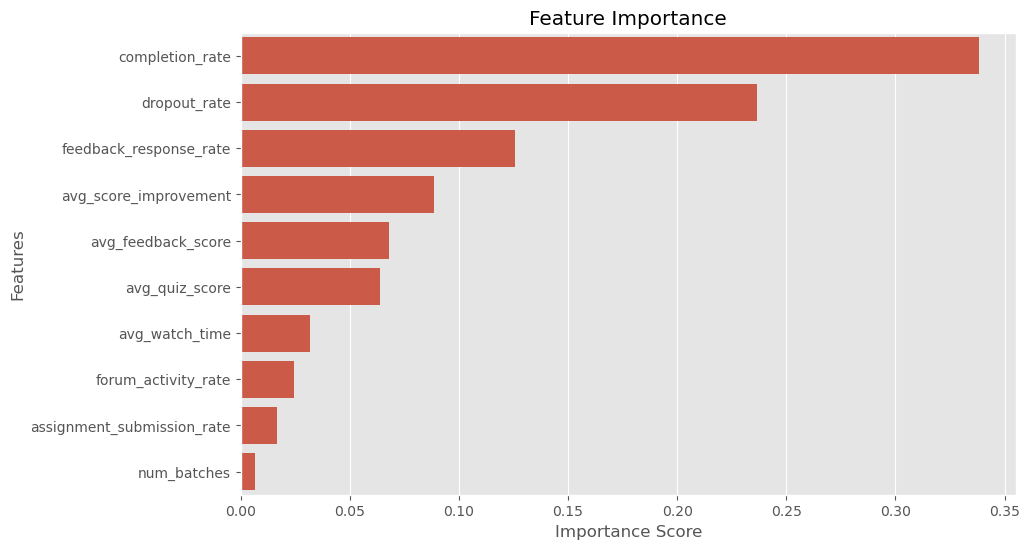

In [96]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Observation

The feature importance analysis reveals that **Completion Rate** is the most influential feature in predicting instructor effectiveness, followed by **Dropout Rate** and **Feedback Response Rate**.

Completion Rate has the highest importance score, indicating that instructors whose learners successfully complete their courses are more likely to be classified as highly effective.

Dropout Rate is the second most important feature, suggesting that lower dropout rates are strongly associated with better instructor performance.

Feedback Response Rate and Average Score Improvement also contribute significantly, highlighting the importance of learner engagement and academic progress in evaluating instructors.

Features such as Average Watch Time, Forum Activity Rate, Assignment Submission Rate, and Number of Batches have relatively lower importance scores, indicating that they have a smaller influence on the model's predictions.

Overall, the model suggests that learner completion, retention, engagement, and academic improvement are the strongest indicators of instructor effectiveness.

## Business Insights

The findings of this analysis provide valuable insights for EdTech platforms:

- Improving learner completion rates can significantly enhance instructor effectiveness.
- Reducing dropout rates should be a key focus for instructors and course designers.
- Encouraging learners to provide feedback can improve the quality of instructor evaluation.
- Monitoring learner score improvements can help identify instructors who positively impact student learning.
- Less influential features, such as the number of batches taught, should not be used alone to evaluate instructor performance.

### 1. Which features most influenced instructor effectiveness, and why?

Based on the Random Forest feature importance analysis, **Completion Rate** was the most influential feature, followed by **Dropout Rate**, **Feedback Response Rate**, and **Average Score Improvement**.

These features directly reflect learner success, retention, engagement, and learning outcomes, making them strong indicators of teaching effectiveness. Higher completion rates and lower dropout rates suggest that instructors are effectively supporting learners throughout the course, while positive feedback and score improvements indicate better learning experiences.

### 2. Which variables could be misleading or confounded?

Some variables may be affected by external factors beyond the instructor's control. For example, course difficulty, learner motivation, prior knowledge, and class size may influence completion rates, quiz scores, and feedback ratings. Therefore, these variables should be interpreted with caution.

### 3. How could this model fail in real-world usage?

The model may not generalize well to new courses, different learner populations, or changing teaching methods. It also cannot measure qualitative aspects of teaching such as communication skills, creativity, or mentorship, which are important components of instructor effectiveness.

### 4. What additional data would improve this analysis?

The analysis could be improved by including additional information such as instructor experience, learner demographics, course difficulty, attendance records, class size, and peer review scores. These factors would provide a more comprehensive assessment of instructor effectiveness.

### 5. Should this model be used for instructor performance evaluation? Why or why not?

This model should be used as a decision-support tool rather than the sole basis for evaluating instructors. While it provides valuable quantitative insights, qualitative factors and human judgment should also be considered to ensure fair and balanced performance evaluations.

## Conclusion

This project successfully analyzed instructor effectiveness using learner performance, engagement, and feedback metrics. Exploratory Data Analysis (EDA) was performed to understand the dataset, followed by feature engineering to create an Instructor Effectiveness Score. Batch-level records were then aggregated into instructor-level data for model training.

Two machine learning models, Logistic Regression and Random Forest Classifier, were developed and evaluated. Logistic Regression achieved an accuracy of **88.89%**, while the Random Forest Classifier achieved a higher accuracy of **94.44%**, making it the best-performing model.

Feature importance analysis showed that **Completion Rate**, **Dropout Rate**, **Feedback Response Rate**, and **Average Score Improvement** were the most influential factors in predicting instructor effectiveness. These findings indicate that learner engagement, course completion, and academic improvement are key indicators of effective teaching.

Overall, this project demonstrates how machine learning can support data-driven decision-making in EdTech. However, instructor evaluations should combine quantitative metrics with qualitative assessments to ensure fair and comprehensive performance evaluation.

## Future Work

- Perform hyperparameter tuning using GridSearchCV.
- Evaluate additional classification models such as XGBoost or Gradient Boosting.
- Incorporate instructor experience and learner demographic information.
- Deploy the trained model using Streamlit or Flask.

---

## Author

**Anushka Verma**

Aspiring Data Scientist | Machine Learning Enthusiast